In [1]:
# Import useful libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

References for special functions

1. $\textit{scipy.special.airy}$ at https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.airy.html#scipy.special.airy
2. $\textit{scipy.special.ai\_zeros}$ at https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.ai_zeros.html#scipy.special.ai_zeros

In [2]:
# Define the Airy function, i.e., Ai(x)
def airy(x):
    return sp.special.airy(x)[0]

In [3]:
# Define the first derivative of the Airy function, i.e., Ai'(x)
def airyp(x):
    return sp.special.airy(x)[1]

In [4]:
# Store the zeros of Ai(x) and Ai'(x)
# The zeros are located in the negative part of the x-axis
# We multiply them by -1 to store their positive values
ai_z, aip_z, _, _ = sp.special.ai_zeros(1000)
ai_z = ai_z * (-1)
aip_z = aip_z * (-1)

In [5]:
# Define the main constants
# Select simple value for simplifying the calculations
# m is the particle's mass
# a, lam and rho are explained in the next chart
# With the following parameters (h^2 / 2m) = 1
hbar = 1.0
m = 0.5
F = 1.0       
lam = 0.01
rho = (hbar**2 / (2 * m * F))**(1 / 3)
rho

1.0

We will use the following notation (Robinett, 2009):

1. The potential is written as follows

\begin{equation}
    \hat{V}=\frac{\hat{p}^{\,2}}{2m}+F|x|+\lambda x.
\end{equation}

2. The odd wavefunctions are written as follows

\begin{equation}
    \psi_n^{odd}(x)=\frac{1}{\sqrt{2}}\text{sgn}(x)\psi_n(|x|)
\end{equation}

where

\begin{equation}
    \psi_n(x)^{} = N_n \,\mathrm{Ai}\left(\frac{x}{\rho} - \zeta_n\right)
\end{equation}

The constants are defined as $N_n = \frac{1}{\sqrt{\rho}\,\mathrm{Ai}'(\zeta_n)}$, $\rho = \left(\frac{\hbar^2}{2mF}\right)^{1/3}$, $\mathcal{E}_0=\rho F$ and $\zeta_n$ is the $n$-th zero of $\mathrm{Ai}(x)$.

3. The even wavefunctions are written as follows

\begin{equation}
    \psi_n^{even}(x) = \frac{1}{\sqrt{2\rho\chi_n}\mathrm{Ai}(-\chi_n)}\mathrm{Ai}\left(\frac{|x|}{\rho} - \chi_n\right)
\end{equation}

where $\chi_n$ is the $n$-th zero of $\mathrm{Ai}^\prime(x)$.



# Wavefunctions

In [6]:
# Odd wavefunction
def wf_odd(n):
    # Input: integer from 1 to n that refers to the n-th odd wavefunctions
    # Output: returns the n-th odd wavefunction \psi_n for evaluating an array of points x
    zero = ai_z[n-1]
    N = 1 / (np.sqrt(rho) * airyp(-1 * zero))
    
    def wf(x):
        x = np.array(x)
        
        return N / np.sqrt(2) * np.where(
            x >= 0,
            airy((x / rho) - zero),
            -1 * airy(-1 * (x / rho) - zero)
        )
    
    return wf

In [7]:
# Even wavefunction
def wf_even(n):
    # Input: integer from 1 to n that refers to the n-th even wavefunctions
    # Output: returns the n-th even wavefunction \psi_n for evaluating an array of points x
    zero = aip_z[n-1]
    N = 1 / (np.sqrt(2 * rho * zero) * airy(-1 * zero))
    
    def wf(x):
        x = np.array(x)
        
        return N * airy((np.abs(x) / rho) - zero)
    
    return wf

# Unperturbed energies

We will use the following notation (Robinett, 2009):

1. The odd energies are defined as 

\begin{equation}
    E_n^{odd} = \rho F \zeta_n
\end{equation}

2. The even energies are defined as follows

\begin{equation}
    E_n^{even} = \rho F \chi_n
\end{equation}


In [8]:
# Odd energies
e_odd = ai_z * rho * F
# Even energies
e_even = aip_z * rho * F

## Examples

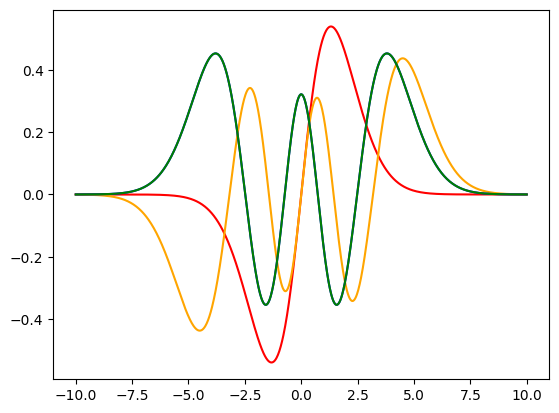

In [9]:
# Plot some wavefunctions to appreciate their symmetry
xdom = np.linspace(-10,10,1000)
plt.plot(xdom, wf_odd(1)(xdom), color = "red")
plt.plot(xdom, wf_odd(3)(xdom), color = "orange")
plt.plot(xdom, wf_even(3)(xdom), color = "blue")
plt.plot(xdom, wf_even(3)(xdom), color = "green")

In [10]:
# Check the normalization condition of an odd wavefunction
result, error = sp.integrate.quad(lambda x: wf_odd(1)(x) * wf_odd(1)(x), -500, 500)
result, error

(0.9999999999999997, 2.2945763102010202e-10)

In [11]:
# Check the normalization condition of an even wavefunction
result2, error2 = sp.integrate.quad(lambda x: wf_even(3)(x) * wf_even(1)(x), -500, 500)
result2, error2

(1.3903808659954109e-15, 9.97648372930409e-10)

In [12]:
# Calculate a matrix element
result3, error3 = sp.integrate.quad(lambda x: wf_even(1)(x) * x * wf_odd(3)(x), -25, 25)
result3

0.02171891008104246

# Python functions for WKB plotting

## WKB 

In [13]:
# WKB energy
def E_WKB_AP(n):
    return rho * F * (3*np.pi / 4)**(2/3) * (n + 1/2)**(2/3) * (1 - (lam**2)/(F**2))**(2/3)

## Exact energy corrections

We will use the following notation (Robinett, 2009):
\begin{equation}
    E_{n,odd}^{(2)} = -\frac{7}{9}\left(\frac{\lambda}{F}\right)^2 \left(\zeta_n\mathcal{E}_0\right)
\end{equation}

\begin{equation}
    E_{n,even}^{(2)} = -\frac{5}{9}\left(\frac{\lambda}{F}\right)^2 \left(\chi_n\mathcal{E}_0\right)
\end{equation}

In [14]:
# Function that returns the second order correction of energy
def E2_exact(parity, n):
    if parity == "odd":
        return -7 / 9 * (lam / F)**2 * e_odd[n-1]
    if parity == "even":
        return -5 / 9 * (lam / F)**2 * e_even[n-1]

## Exact energy after perturbation

In [15]:
# Function that returns the exact energy after perturbation
# E = E0 + E2
def E_EX(parity, n):

    if parity == "odd":
        return e_odd[n-1] + E2_exact(parity, n)
    else:
        return e_even[n-1] + E2_exact(parity, n)

# Plots of WKB

In [16]:
# Number of points
N = 25
# Interval in x
x_interval = np.arange(1, N + 1)

### WKB energies after perturbation

In [17]:
E_WKB = np.zeros(N)

for i in range(0, N):
    E_WKB[i] = E_WKB_AP(i)


### Exact energy after perturbation

In [18]:
# Exact
E_even_EX = np.zeros(N)
E_odd_EX = np.zeros(N)

for i in range(0, N):
    E_even_EX[i] = E_EX("even", i + 1)
    E_odd_EX[i] = E_EX("odd", i + 1)

It is important to mention that WKB method does not dintinguish the parity of the wavefunctions. Therefore, to compare the WKB energies with the reference values of each parity, we must alternate between even and odd states.

In [19]:
E_even_EX_nan = np.zeros(N)
E_odd_EX_nan = np.zeros(N)

E_parity_alternated = np.zeros(N)

count_even = 0
count_odd = 0

for i in range(0, N): 
    if i%2 == 0:
        E_parity_alternated[i] = E_even_EX[count_even]
        E_even_EX_nan[i] = E_even_EX[count_even]
        E_odd_EX_nan[i] = np.nan
        count_even += 1
    if i%2 == 1: 
        E_parity_alternated[i] = E_odd_EX[count_odd]
        E_even_EX_nan[i] = np.nan
        E_odd_EX_nan[i] = E_odd_EX[count_odd]
        count_odd += 1



### Plots

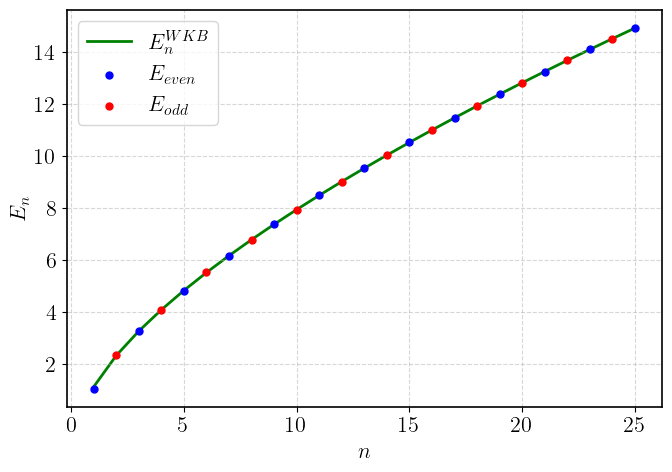

In [25]:
# Activate Latex style
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 1.2,
})

plt.figure(figsize=(7,5))

plt.plot(x_interval, E_WKB, label=r"$E_{n}^{WKB}$", linewidth=2, color = "green", zorder = 1)
plt.scatter(x_interval, E_even_EX_nan, label=r"$E_{even}$", s=25, color = "blue", zorder = 2)
plt.scatter(x_interval, E_odd_EX_nan, label=r"$E_{odd}$", s=25, color = "red", zorder = 2)

plt.xlabel(r"$n$")
plt.ylabel(r"$E_n$")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig("new_wkb_energies.pdf", bbox_inches='tight', transparent=True)

plt.show()

### Deviation of WKB energies

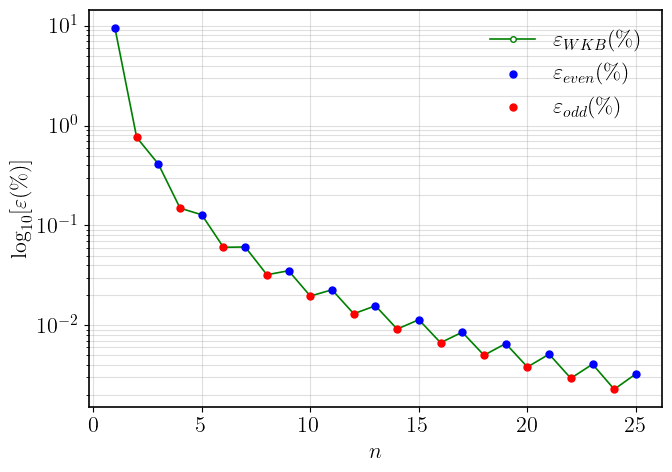

In [23]:
relative_error_WKB = np.where(E_WKB != 0,
              np.abs(E_WKB - E_parity_alternated) / np.abs(E_parity_alternated) * 100,
              np.nan)

relative_error_even_EX_nan = np.where(E_WKB != 0,
              np.abs(E_WKB - E_even_EX_nan) / np.abs(E_even_EX_nan) * 100,
              np.nan)

relative_error_odd_EX_nan = np.where(E_WKB != 0,
              np.abs(E_WKB - E_odd_EX_nan) / np.abs(E_odd_EX_nan) * 100,
              np.nan)

fig, ax = plt.subplots(figsize=(7,5))

ax.plot(x_interval, relative_error_WKB,
        color='green',
        marker='o',
        markersize=4,
        markerfacecolor='white',
        linewidth=1.2,
        label= r"$\varepsilon_{WKB}(\%)$")

plt.scatter(x_interval, relative_error_even_EX_nan, label=r"$\varepsilon_{even}(\%)$", s=25, color = "blue", zorder = 2)

plt.scatter(x_interval, relative_error_odd_EX_nan, label=r"$\varepsilon_{odd}(\%)$", s=25, color = "red", zorder = 2)

ax.set_xlabel(r"$n$")
ax.set_ylabel(r"$\log_{10}[\varepsilon(\%)$]")

ax.set_xticks([0, 5, 10, 15, 20, 25])

ax.grid(True, which="both", alpha=0.4)

ax.legend(frameon=False)

plt.yscale('log')

plt.tight_layout()

# Save as PDF
plt.savefig("new_deviation_wkb.pdf", bbox_inches='tight', transparent=True)

plt.show()